In [1]:
import ee
import geemap
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import joblib
import seaborn as sns
import matplotlib.pyplot as plt
from typing import List, Tuple

In [2]:
# Name of project in google cloud available to use with Earth Engine
EE_PROJECT = "ee-gis-scode"

try:
    ee.Authenticate()
    if EE_PROJECT:
        ee.Initialize(project=EE_PROJECT)
    else:
        ee.Initialize()
except Exception as e:
    raise RuntimeError(
        "Failed to initialize the Earth Engine client. "
    ) from e

In [3]:
# --- 1. Definir Área de Interés (AOI) ---
# Usaremos las coordenadas de Cuenca.
# Recommendation: Para un análisis más preciso, podrías cargar un shapefile.
# Using FAO GAUL dataset to get country boundaries
countries_dataset = ee.FeatureCollection("FAO/GAUL_SIMPLIFIED_500m/2015/level2");

cuenca_ecuador = countries_dataset.filter(ee.Filter.eq('ADM1_NAME', 'Azuay')) \
                                .filter(ee.Filter.eq('ADM2_NAME', 'Cuenca'))

cuenca_aoi = cuenca_ecuador.geometry()

# xmin, ymin = -79.350128,-2.992413
# xmax, ymax = -78.932648,-2.720840
# cuenca_aoi = ee.Geometry.Rectangle([xmin, ymin, xmax, ymax])

Map = geemap.Map()
Map.centerObject(cuenca_aoi, 10)
Map.addLayer(cuenca_aoi, {'color':'red'}, "Cuenca AOI")
# Map.addLayer(geometry, {'color':'blue'}, "Cuenca Geometry")
display(Map)

Map(center=[-2.8614150694256804, -79.2200132598867], controls=(WidgetControl(options=['position', 'transparent…

In [5]:
# --- 2. Cargar el Dataset de Hansen Global Forest Change ---
# indica el año en que se perdió la cobertura forestal.
# Se le pides a GEE que dé acceso a todo el dataset.
hansen_dataset = ee.Image("UMD/hansen/global_forest_change_2024_v1_12")
print("Dataset de Hansen cargado.")
# --- 3. Seleccionar las Bandas de Interés ---
# Extraemos las dos "capas" que nos importan de la super-imagen.
#treecover2000: Una capa que muestra el porcentaje de cobertura de árboles en el año 2000. La usaremos para definir dónde había bosque originalmente.
#lossyear: Una capa donde el valor de cada píxel indica el año en que se perdió el bosque (si es que se perdió). Un valor de 23 significa que la pérdida ocurrió en 2023.
tree_cover_2000 = hansen_dataset.select(['treecover2000'])
loss_year = hansen_dataset.select(['lossyear'])
gain = hansen_dataset.select(['gain']) # También consideraremos la ganancia de bosque
# CLASE 2: DEFORESTADO (Deforestación)

deforested_mask = loss_year.gte(1)

# CLASE 1: BOSQUE ESTABLE (Lógica Flexible)
# Un píxel es "Bosque" si:
# a) Tenía más de 30% de cobertura en el año 2000.
forest_mask = tree_cover_2000.gte(30)

Dataset de Hansen cargado.


In [6]:

# --- 3. Crear la Imagen de Etiquetas Unificada ---
# Este es el paso más importante para el entrenamiento del modelo.

# Empezamos con una imagen donde todo es 0 (Clase 0: Otras Tierras)
label_image = ee.Image(0).clip(cuenca_aoi)

# "Pintamos" los píxeles de bosque con el valor 1
label_image = label_image.where(forest_mask, 1)

# "Pintamos" los píxeles deforestados con el valor 2.
# Esta línea sobreescribe los píxeles de bosque que fueron deforestados.
label_image = label_image.where(deforested_mask, 2)

# --- 4. Visualización para Verificación ---
Map = geemap.Map()
Map.centerObject(cuenca_aoi, 10)
Map.setOptions('HYBRID')

# Paleta de colores para las clases: 0 (Gris), 1 (Verde), 2 (Rojo)
label_palette = ['#AAAAAA', '#008000', '#FF0000']

Map.addLayer(label_image, {'min': 0, 'max': 2, 'palette': label_palette}, 'Mapa de Etiquetas para Entrenamiento')

Map.add_legend(title="Leyenda de Clases", legend_dict={
    "Otras Tierras (Clase 0)": "#AAAAAA",
    "Bosque (Clase 1)": "#008000",
    "Deforestado 2024 (Clase 2)": "#FF0000"
})

display(Map)

Map(center=[-2.8614150694256804, -79.2200132598867], controls=(WidgetControl(options=['position', 'transparent…

In [9]:
# --- CONSTANTES GLOBALES (Se asume que cuenca_aoi ya está definida) ---
CLOUD_SCORE_COLLECTION = 'GOOGLE/CLOUD_SCORE_PLUS/V1/S2_HARMONIZED'
SENTINEL_COLLECTION = 'COPERNICUS/S2_SR_HARMONIZED'
MAX_CLOUD_PERCENTAGE = 35
CLEAR_THRESHOLD = 0.6  # Umbral de claridad (0.6 = 60% claro)

# --- 1. FUNCIÓN DE ENMASCARAMIENTO (Cloud Score Plus) ---
def mask_s2_cs_plus(image):
    """
    Aplica una máscara de nubes y sombras usando la banda 'cs' y reescala las bandas.
    """
    # 1. Crear la máscara: cs >= 0.6
    qaBand = 'cs'
    mask = image.select(qaBand).gte(CLEAR_THRESHOLD)
    
    # 2. Reescalar y aplicar la máscara (S2_SR está en 0-10000, dividimos por 10000)
    return image.updateMask(mask).divide(10000)

# --- 2. FUNCIÓN PARA CREAR CUALQUIER COMPOSICIÓN ANUAL LIBRE DE NUBES ---
def get_annual_composite(year: int, aoi: ee.Geometry) -> ee.Image:
    """
    Crea una composición mediana (medoid) libre de nubes para un año específico
    usando el método linkCollection y el enmascaramiento Cloud Score Plus.
    """
    start_date = f'{year}-01-01'
    end_date = f'{year}-12-31'
    
    # a. Colección base (S2_SR)
    s2_collection = ee.ImageCollection(SENTINEL_COLLECTION)\
        .filterDate(start_date, end_date)\
        .filterBounds(aoi)\
        .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', MAX_CLOUD_PERCENTAGE))

    # b. Colección de scores (CSP) y unión (linkCollection)
    cs_plus = ee.ImageCollection(CLOUD_SCORE_COLLECTION).filterDate(start_date, end_date)
    collection_with_cs = s2_collection.linkCollection(cs_plus, ['cs'])

    # c. Aplicar Máscara y Composición Mediana
    collection_sin_nubes = collection_with_cs.map(mask_s2_cs_plus)
    median_composite = collection_sin_nubes.median().clip(aoi)
    
    return median_composite

# --- 3. CREACIÓN DE TODAS LAS CARACTERÍSTICAS (SPECTRALES, TEMPORALES, TOPOGRÁFICAS) ---
print("--- INICIANDO CREACIÓN DE CARACTERÍSTICAS MEJORADAS ---")

# 3.1. Composiciones Mediana 2024 y 2023 (Usando el nuevo enmascaramiento)
composite_2024 = get_annual_composite(2024, cuenca_aoi)
composite_2023 = get_annual_composite(2023, cuenca_aoi)
print("Composiciones 2024 y 2023 listas.")

# 3.2. CARACTERÍSTICAS TEMPORALES
# Esto es vital: La diferencia de vegetación entre años es el principal indicador de deforestación.
ndvi_2024 = composite_2024.normalizedDifference(['B8', 'B4']).rename('NDVI_2024')
ndvi_2023 = composite_2023.normalizedDifference(['B8', 'B4']).rename('NDVI_2023')
ndvi_diff = ndvi_2024.subtract(ndvi_2023).rename('NDVI_diff')
print("Índice de diferencia temporal (NDVI_diff) calculado.")


# 3.3. CARACTERÍSTICAS DE ÍNDICES ESPECTRALES (Basado en 2024)
# (NDVI, EVI, SAVI, NDWI)
b2 = composite_2024.select('B2').rename('Blue')
b3 = composite_2024.select('B3').rename('Green')
b4 = composite_2024.select('B4').rename('Red')
b8 = composite_2024.select('B8').rename('NIR')

ndvi = b8.subtract(b4).divide(b8.add(b4)).rename('NDVI')
evi = composite_2024.expression(
    '2.5 * ((NIR - RED) / (NIR + 6 * RED - 7.5 * BLUE + 1))', {
        'NIR': b8, 'RED': b4, 'BLUE': b2
    }).rename('EVI')
savi = composite_2024.expression(
    '((NIR - RED) / (NIR + RED + 0.5)) * 1.5', {
        'NIR': b8, 'RED': b4
    }).rename('SAVI')
ndwi = b3.subtract(b8).divide(b3.add(b8)).rename('NDWI')
print("Índices espectrales (NDVI, EVI, SAVI, NDWI) calculados.")


# 3.4. CARACTERÍSTICAS AUXILIARES (TOPOGRAFÍA Y TEXTURA)

# TOPOGRAFÍA (DEM y Slope)
# Aunque parezcan irrelevantes, la topografía ayuda a contextualizar si el área
# clasificada como "Deforestado" está en un sitio donde la deforestación es común.
dem = ee.Image('USGS/SRTMGL1_003').clip(cuenca_aoi)
elevation = dem.select('elevation')
slope = ee.Terrain.slope(dem).rename('slope')
print("Características de topografía listas.")

# TEXTURA (Entropy de GLCM)
# La textura (entropía) diferencia un bosque denso (uniforme) de un área
# deforestada y fragmentada (alta entropía).
# Se usa NIR (B8) y se convierte a entero para la función GLCM.
nir_integer = b8.multiply(1000).toInt16()
glcm = nir_integer.glcmTexture(size=4)
entropy = glcm.select('NIR_ent').rename('entropy') # Usamos el nuevo nombre 'NIR'
print("Característica de textura (Entropy) calculada.")

# 3.5. COMBINAR Y SELECCIONAR BANDAS FINALES

# Lista de todas las bandas a incluir en el modelo
# Incluimos las bandas espectrales renombradas
BANDS_TO_SELECT = ['Blue', 'Green', 'Red', 'NIR', 'NDVI', 'EVI', 'SAVI', 'NDWI', 'NDVI_diff', 'elevation', 'slope', 'entropy']

# Juntamos todas las características en una sola imagen.
final_features = composite_2024.select(['B2', 'B3', 'B4', 'B8'])\
    .rename(['Blue', 'Green', 'Red', 'NIR'])\
    .addBands([ndvi, evi, savi, ndwi, ndvi_diff, elevation, slope, entropy])

# Aseguramos que solo tengamos las bandas deseadas y en el orden correcto
final_features = final_features.select(BANDS_TO_SELECT)


print("\n--- ¡PROCESO FINALIZADO! ---")
print("Imagen final de características creada con todas las bandas.")
print("Bandas disponibles para el modelo:", final_features.bandNames().getInfo())

--- INICIANDO CREACIÓN DE CARACTERÍSTICAS MEJORADAS ---
Composiciones 2024 y 2023 listas.
Índice de diferencia temporal (NDVI_diff) calculado.
Índices espectrales (NDVI, EVI, SAVI, NDWI) calculados.
Características de topografía listas.
Característica de textura (Entropy) calculada.

--- ¡PROCESO FINALIZADO! ---
Imagen final de características creada con todas las bandas.
Bandas disponibles para el modelo: ['Blue', 'Green', 'Red', 'NIR', 'NDVI', 'EVI', 'SAVI', 'NDWI', 'NDVI_diff', 'elevation', 'slope', 'entropy']


In [ ]:
from sklearn.model_selection import GridSearchCV
def create_training_data(feature_image: ee.Image, label_image: ee.Image, aoi: ee.Geometry, 
                           num_points: int, scale: int, class_band: str) -> Tuple[ee.FeatureCollection, ee.FeatureCollection]:
    """
    Crea datos de entrenamiento y prueba mediante muestreo estratificado en GEE.
    """
    print("Paso 1: Iniciando muestreo estratificado...")
    
    # Unimos features y etiquetas en una sola imagen para el muestreo.
    training_image = feature_image.addBands(label_image)

    # Realizamos el muestreo, asegurando un número igual de puntos por clase.
    stratified_samples = training_image.stratifiedSample(
        numPoints=num_points,
        classBand=class_band,
        projection='EPSG:4326',
        scale=scale,
        region=aoi,
        geometries=True  # Incluir la geometría de los puntos
    ).randomColumn()  # Añade una columna aleatoria para la división train/test

    # Dividimos los datos: 70% para entrenamiento, 30% para prueba.
    training_data = stratified_samples.filter(ee.Filter.lt('random', 0.7))
    testing_data = stratified_samples.filter(ee.Filter.gte('random', 0.7))
    
    print(f"Muestreo completado. Se dividirán los puntos para entrenamiento y prueba.")
    return training_data, testing_data

def prepare_sklearn_data(training_gee: ee.FeatureCollection, testing_gee: ee.FeatureCollection, 
                           features: List[str], target: str) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """
    Convierte los FeatureCollections de GEE a DataFrames de Pandas y los prepara para scikit-learn.
    """
    print("Paso 2: Convirtiendo datos a DataFrames y preparando para el modelo...")
    
    # Convertimos los datos de GEE a Pandas DataFrames
    training_df = geemap.ee_to_df(training_gee)
    testing_df = geemap.ee_to_df(testing_gee)

    # Limpiamos los datos eliminando filas con valores nulos en nuestras columnas de interés.
    training_df.dropna(subset=features + [target], inplace=True)
    testing_df.dropna(subset=features + [target], inplace=True)

    # Separamos las características (X) del objetivo (y)
    X_train, y_train = training_df[features], training_df[target]
    X_test, y_test = testing_df[features], testing_df[target]

    print(f"Datos listos: {len(X_train)} muestras de entrenamiento, {len(X_test)} muestras de prueba.")
    return X_train, y_train, X_test, y_test, training_df, testing_df

def train_and_evaluate_model(X_train: pd.DataFrame, y_train: pd.Series, X_test: pd.DataFrame, y_test: pd.Series) -> RandomForestClassifier:
    """
    Entrena un modelo RandomForest y evalúa su rendimiento.
    """
    print("\nPaso 3: Iniciando la optimización de hiperparámetros con GridSearchCV...")

    # 1. Define la rejilla de parámetros que quieres probar
    #    ¡Advertencia! Una rejilla grande puede tardar mucho tiempo en ejecutarse.
    #    Esta es una rejilla de ejemplo, puedes reducirla para pruebas más rápidas.
    param_grid = {
        'n_estimators': [100, 200],         # Número de árboles
        'max_depth': [10, 20, None],       # Profundidad máxima
        'min_samples_split': [2, 5],       # Mínimo de muestras para dividir
        'min_samples_leaf': [1, 2]         # Mínimo de muestras por hoja
    }

    # 2. Inicializa el modelo base
    rf = RandomForestClassifier(random_state=42, class_weight="balanced")

    # 3. Configura y ejecuta GridSearchCV
    #    cv=3 significa validación cruzada de 3 pliegues.
    #    n_jobs=-1 usa todos los núcleos de tu CPU para acelerar el proceso.
    #    verbose=2 te mostrará el progreso.
    grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5, n_jobs=-1, verbose=2)
    grid_search.fit(X_train, y_train)

    # 4. Obtén el mejor modelo y sus parámetros
    print("\n¡Optimización completada!")
    print(f"Los mejores parámetros encontrados son: {grid_search.best_params_}")
    best_model = grid_search.best_estimator_

    # 5. Evalúa el rendimiento del MEJOR modelo
    print("\nPaso 4: Evaluando el rendimiento del modelo optimizado...")
    y_pred = best_model.predict(X_test)
    
    # Generar y mostrar el reporte de clasificación
    class_labels = ['Otras Tierras (0)', 'Bosque (1)', 'Deforestado (2)']
    report = classification_report(y_test, y_pred, target_names=class_labels)
    print("\nReporte de Clasificación:")
    print(report)

    # Generar y guardar la matriz de confusión
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_labels, yticklabels=class_labels)
    plt.title('Matriz de Confusión')
    plt.ylabel('Clase Real')
    plt.xlabel('Clase Predicha')
    plt.savefig('confusion_matrix_optimized.png')
    print("\nMatriz de confusión guardada como 'confusion_matrix_optimized.png'")
    
    return best_model

def save_artifacts(classifier: RandomForestClassifier, training_df: pd.DataFrame, testing_df: pd.DataFrame, model_filename: str):
    """
    Guarda el modelo entrenado y los DataFrames de muestra.
    """
    print("\nPaso 5: Guardando el modelo y los datos de muestra...")
    joblib.dump(classifier, model_filename)
    training_df.to_csv('training_samples.csv', index=False)
    testing_df.to_csv('testing_samples.csv', index=False)
    print(f"¡PROCESO COMPLETADO! Modelo guardado como '{model_filename}'")

Paso 1: Iniciando muestreo estratificado...
Muestreo completado. Se dividirán los puntos para entrenamiento y prueba.
Paso 2: Convirtiendo datos a DataFrames y preparando para el modelo...
Datos listos: 8417 muestras de entrenamiento, 3583 muestras de prueba.

Paso 3: Iniciando la optimización de hiperparámetros con GridSearchCV...
Fitting 3 folds for each of 24 candidates, totalling 72 fits
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=5, n_estimators=100; total time=   1.8s
[CV] END max_depth=10, min_samples_leaf=2, min_samples_split=2, n_estimators=100; total time=   1.8s
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=5, n_estimators=100; total time=   1.8s
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   1.8s
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   1.8s
[CV] END max_depth=10, min_samples_leaf=2, min_samples_split=2, n_estimators=100; total time=   1.8s

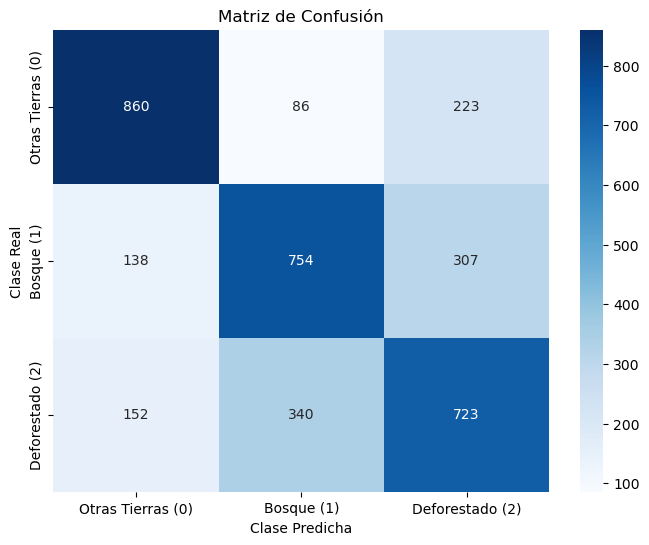

In [12]:
BANDS = BANDS_TO_SELECT
CLASS_BAND = 'class'
POINTS_PER_CLASS = 4000   # aumentar muestras por clase (ajusta según tiempo/recursos)
SCALE = 10                # usar 10 m para Sentinel-2
MODEL_FILENAME = 'deforestation_model_v4.pkl'

# 1. Crear datos de entrenamiento y prueba
class_labels_image = label_image.select('constant').rename(CLASS_BAND)

# *** LA CORRECCIÓN ESTÁ AQUÍ ***
# Pasamos la imagen `final_features` que SÍ CONTIENE 'NDVI_diff'
training_gee, testing_gee = create_training_data(
    feature_image=final_features,
    label_image=class_labels_image,
    aoi=cuenca_aoi,
    num_points=POINTS_PER_CLASS,
    scale=SCALE,
    class_band=CLASS_BAND
)

# 2. Preparar los datos para scikit-learn
# Usamos la lista de bandas correcta que coincide con la imagen
X_train, y_train, X_test, y_test, train_df, test_df = prepare_sklearn_data(
    training_gee=training_gee,
    testing_gee=testing_gee,
    features=BANDS,
    target=CLASS_BAND
)

# 3. Entrenar y evaluar el modelo
trained_model = train_and_evaluate_model(X_train, y_train, X_test, y_test)

# 4. Guardar los artefactos finales
save_artifacts(trained_model, train_df, test_df, MODEL_FILENAME)